# Notebook — Teste do módulo `geodynamics.py`

Este notebook testa o módulo:

```python
geodesy/geodynamics.py
```

Serão testadas as funções:

- `linear_velocity_model`
- `estimate_linear_velocity`
- `seasonal_signal`
- `fit_seasonal_signal`
- `postseismic_log_decay`
- `sea_level_trend`

Os exemplos simulam séries temporais GNSS/geodésicas com tendência, sazonalidade, relaxação pós-sísmica e nível do mar.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")

import geodesy
from geodesy import geodynamics

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Modelo linear de velocidade


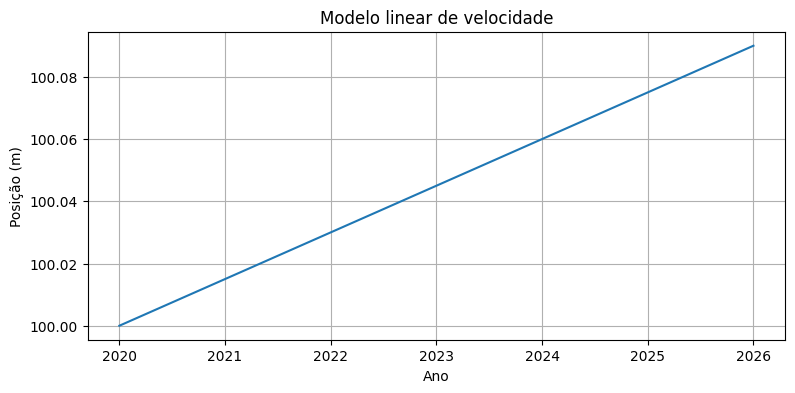

In [2]:
# ============================================================
# 1. MODELO LINEAR
# ============================================================

t = np.linspace(2020, 2026, 300)

x0 = 100.0
v = 0.015  # m/ano

x_model = geodynamics.linear_velocity_model(t, x0, v, t0=2020)

plt.figure(figsize=(9, 4))
plt.plot(t, x_model)
plt.xlabel("Ano")
plt.ylabel("Posição (m)")
plt.title("Modelo linear de velocidade")
plt.grid(True)
plt.show()


## 2. Estimativa de velocidade linear


x0 verdadeiro: 100.0
v verdadeiro: 0.015

x0 estimado: 99.99973287941089
v estimado: 0.014952110516343296


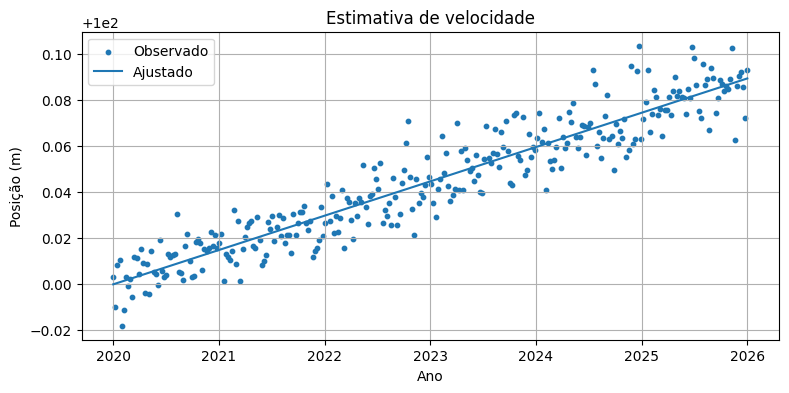

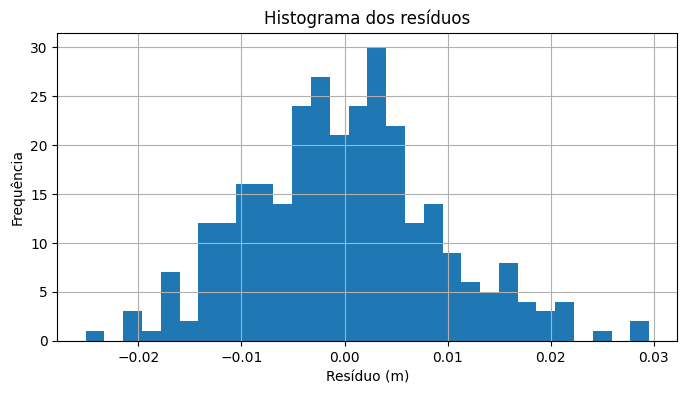

In [3]:
# ============================================================
# 2. ESTIMA VELOCIDADE
# ============================================================

rng = np.random.default_rng(42)

noise = rng.normal(0, 0.01, size=len(t))
x_obs = x_model + noise

x0_est, v_est = geodynamics.estimate_linear_velocity(t - 2020, x_obs)

print("x0 verdadeiro:", x0)
print("v verdadeiro:", v)

print("\nx0 estimado:", x0_est)
print("v estimado:", v_est)

x_fit = geodynamics.linear_velocity_model(t - 2020, x0_est, v_est)

plt.figure(figsize=(9, 4))
plt.scatter(t, x_obs, s=10, label="Observado")
plt.plot(t, x_fit, label="Ajustado")
plt.xlabel("Ano")
plt.ylabel("Posição (m)")
plt.title("Estimativa de velocidade")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(x_obs - x_fit, bins=30)
plt.xlabel("Resíduo (m)")
plt.ylabel("Frequência")
plt.title("Histograma dos resíduos")
plt.grid(True)
plt.show()


## 3. Sinal sazonal


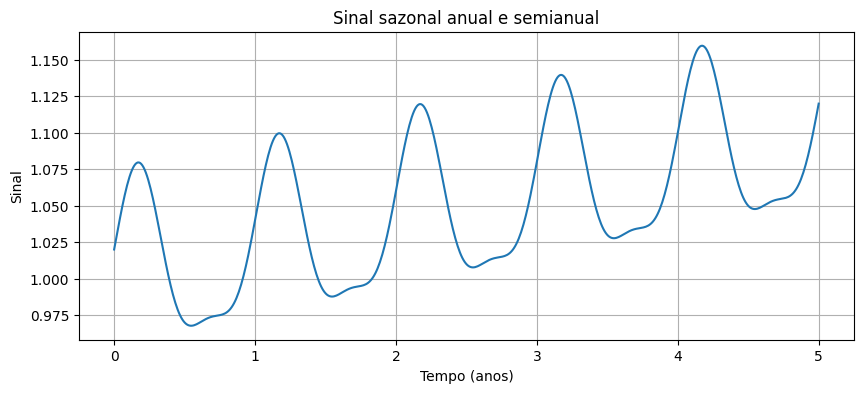

In [4]:
# ============================================================
# 3. SINAL SAZONAL
# ============================================================

t_rel = np.linspace(0, 5, 600)

season = geodynamics.seasonal_signal(
    t_rel,
    offset=1.0,
    trend=0.02,
    annual_sin=0.05,
    annual_cos=0.03,
    semi_sin=0.015,
    semi_cos=-0.01
)

plt.figure(figsize=(10, 4))
plt.plot(t_rel, season)
plt.xlabel("Tempo (anos)")
plt.ylabel("Sinal")
plt.title("Sinal sazonal anual e semianual")
plt.grid(True)
plt.show()


## 4. Ajuste de sinal sazonal


Coeficientes ajustados:
[ 1.00054661  0.01960022  0.04988021  0.02994553  0.01548597 -0.00971801]


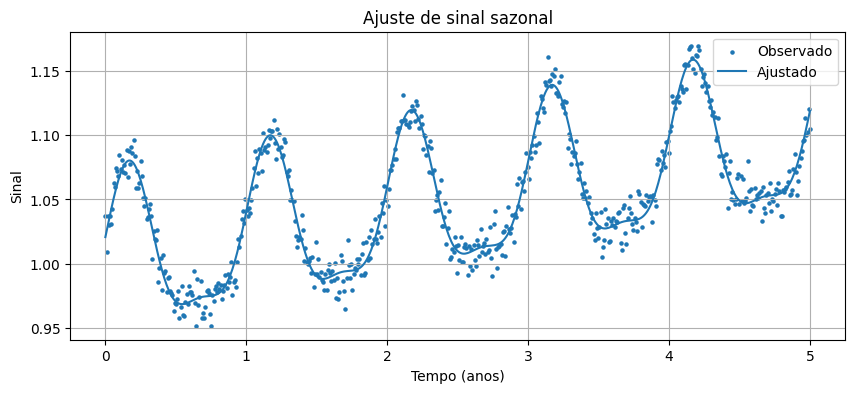

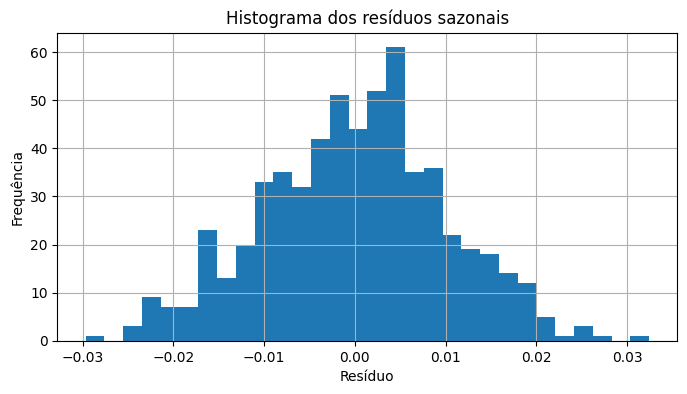

In [5]:
# ============================================================
# 4. AJUSTE SAZONAL
# ============================================================

obs_season = season + rng.normal(0, 0.01, size=len(t_rel))

coef = geodynamics.fit_seasonal_signal(t_rel, obs_season)

print("Coeficientes ajustados:")
print(coef)

season_fit = geodynamics.seasonal_signal(
    t_rel,
    offset=coef[0],
    trend=coef[1],
    annual_sin=coef[2],
    annual_cos=coef[3],
    semi_sin=coef[4],
    semi_cos=coef[5]
)

plt.figure(figsize=(10, 4))
plt.scatter(t_rel, obs_season, s=5, label="Observado")
plt.plot(t_rel, season_fit, label="Ajustado")
plt.xlabel("Tempo (anos)")
plt.ylabel("Sinal")
plt.title("Ajuste de sinal sazonal")
plt.legend()
plt.grid(True)
plt.show()

res = obs_season - season_fit

plt.figure(figsize=(8, 4))
plt.hist(res, bins=30)
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Histograma dos resíduos sazonais")
plt.grid(True)
plt.show()


## 5. Decaimento pós-sísmico logarítmico


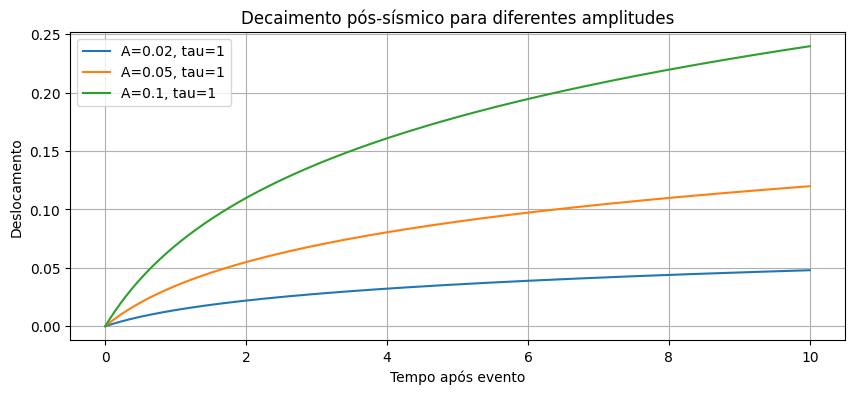

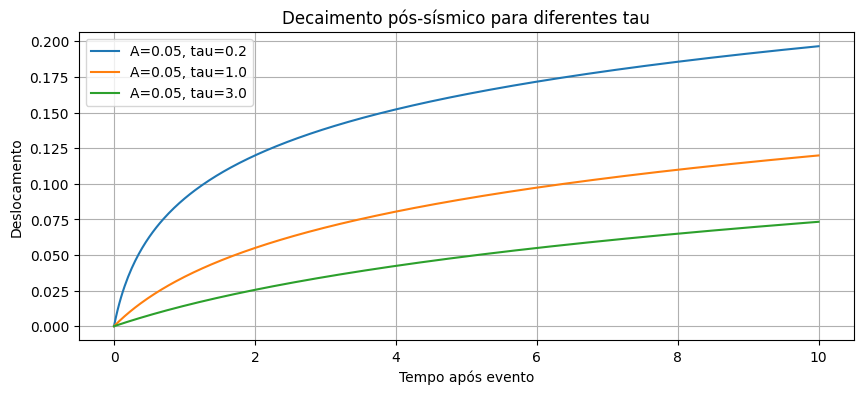

In [6]:
# ============================================================
# 5. DECAIMENTO PÓS-SÍSMICO
# ============================================================

t_post = np.linspace(0, 10, 400)

A_values = [0.02, 0.05, 0.1]
tau_values = [0.2, 1.0, 3.0]

plt.figure(figsize=(10, 4))

for A in A_values:
    y = geodynamics.postseismic_log_decay(t_post, A=A, tau=1.0, t0=0.0)
    plt.plot(t_post, y, label=f"A={A}, tau=1")

plt.xlabel("Tempo após evento")
plt.ylabel("Deslocamento")
plt.title("Decaimento pós-sísmico para diferentes amplitudes")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))

for tau in tau_values:
    y = geodynamics.postseismic_log_decay(t_post, A=0.05, tau=tau, t0=0.0)
    plt.plot(t_post, y, label=f"A=0.05, tau={tau}")

plt.xlabel("Tempo após evento")
plt.ylabel("Deslocamento")
plt.title("Decaimento pós-sísmico para diferentes tau")
plt.legend()
plt.grid(True)
plt.show()


## 6. Tendência do nível do mar


Offset estimado: 0.0018230987739626405
Tendência estimada: 0.003371357748699401 m/ano
Tendência estimada: 3.371357748699401 mm/ano


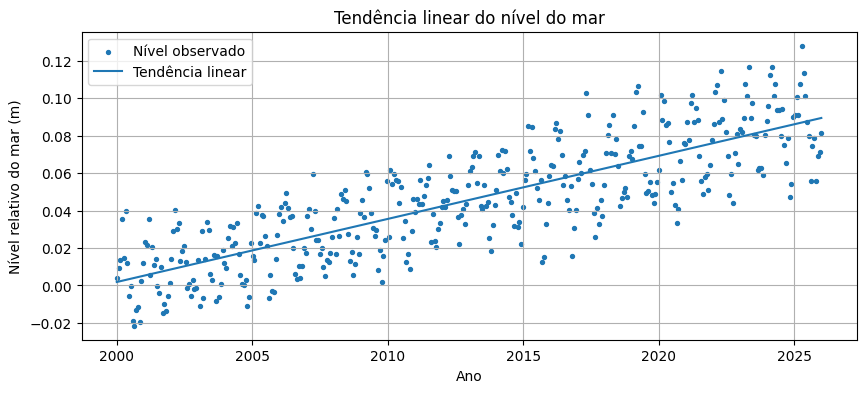

In [7]:
# ============================================================
# 6. TENDÊNCIA DO NÍVEL DO MAR
# ============================================================

t_sea = np.linspace(2000, 2026, 400)
sea_true = 0.0035*(t_sea - 2000) + 0.02*np.sin(2*np.pi*(t_sea - 2000))
sea_obs = sea_true + rng.normal(0, 0.01, size=len(t_sea))

offset_sea, trend_sea = geodynamics.sea_level_trend(t_sea - 2000, sea_obs)

print("Offset estimado:", offset_sea)
print("Tendência estimada:", trend_sea, "m/ano")
print("Tendência estimada:", trend_sea*1000, "mm/ano")

sea_fit = geodynamics.linear_velocity_model(t_sea - 2000, offset_sea, trend_sea)

plt.figure(figsize=(10, 4))
plt.scatter(t_sea, sea_obs, s=8, label="Nível observado")
plt.plot(t_sea, sea_fit, label="Tendência linear")
plt.xlabel("Ano")
plt.ylabel("Nível relativo do mar (m)")
plt.title("Tendência linear do nível do mar")
plt.legend()
plt.grid(True)
plt.show()


## 7. Mapa temporal sintético


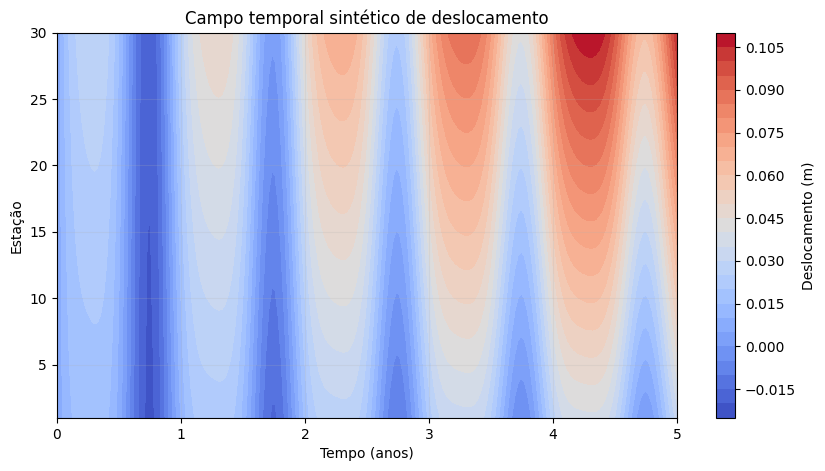

In [9]:
# ============================================================
# 7. MAPA TEMPO x ESTAÇÃO
# ============================================================

stations = np.arange(1, 31)
time = np.linspace(0, 5, 200)

TIME, STATION = np.meshgrid(time, stations)

velocity_station = 0.005 + 0.0005*STATION
season_amp = 0.02 + 0.0003*STATION

DISP = (
    velocity_station*TIME
    + season_amp*np.sin(2*np.pi*TIME)
    + 0.005*np.cos(4*np.pi*TIME)
)

plt.figure(figsize=(10, 5))
c = plt.contourf(TIME, STATION, DISP, cmap="coolwarm", levels=30)
plt.colorbar(c, label="Deslocamento (m)")
plt.xlabel("Tempo (anos)")
plt.ylabel("Estação")
plt.title("Campo temporal sintético de deslocamento")
plt.grid(alpha=0.2)
plt.show()


## 8. Resumo final


Se todas as células foram executadas sem erro, o módulo `geodynamics.py` está funcionando corretamente.

Ainda podemos criar posteriormente um notebook específico para:

```python
geodesy/io.py
```

e depois o notebook final de estimativa do geoide a partir dos seus arquivos reais.
